# Phase 2 — Notebook 01 · Single-session E1 feasibility (Stage 2.1)

**Scope.** This notebook implements **Stage 2.1** of `PHASE2_PLANNING.md`: a within-session feasibility test of a small 1-D CNN on E1 (one row per `(neuron, hash)`, trial-averaged within hash) trained on padded oracle calcium traces from one balanced low-mismatch session.

**Scientific question.** Within a single, label-clean, layer-balanced session, can a shallow temporal CNN learn layer-discriminative structure from raw calcium traces beyond (i) trace baseline offset, (ii) the marginal amplitude distribution, and (iii) the temporal order of the response? This is **not** the headline cross-session result — it is an architecture and pipeline feasibility check (planning §0, §1.2, §10).

**Benchmark posture.** Engineered-feature benchmarks (Tier G, Tier A, …) are deferred to the *end-of-Phase-2* benchmark notebook. This notebook is **CNN-only** and reports model vs. control deltas (planning §6 framing of intra-CNN comparisons).

**Methodological contract** (binding rules from `PHASE2_PLANNING.md`):

1. **Population.** Working pool of V1-excitatory best-only neurons, with mismatch (EM `layer_label` ≠ celltype-implied layer) neurons removed *before* anything else (§1.3).
2. **Session.** One balanced four-class session — **5_6** (highest layer-balance entropy among non-degenerate sessions, very low mismatch in Phase-1 sensitivity analyses; §1.4, §7-Stage 2.1).
3. **Representation.** E1 = `(nucleus_id × oracle condition_hash)` with the within-hash trial-averaged trace `response_avg` (§2.2). All three families (Clip / Monet2 / Trippy) are pooled with **one shared encoder**; traces are zero-padded to `MAX_TRACE_LEN = 113` and a validity mask is carried through the masked global-average pool so padded frames cannot contribute to the trace embedding (§3.1, §3.2).
4. **Cross-validation.** **GroupKFold by `nucleus_id`**, 5 folds (§6.4). Inside each fold the next fold (mod 5) is held out as a validation set for early stopping. No neuron ever appears in more than one of `{train, val, test}` → strictly no row leakage.
5. **Scoring.** Train on rows; score on **neurons** by **mean-of-probabilities** aggregation (E1 hash-uniform aggregation; §6.1, §6.2). Primary metric: balanced accuracy. Secondaries: macro-F1, per-class recall, confusion matrix.
6. **Loss.** Class-weighted cross-entropy with weights computed on **unique training neurons** (not rows), so high-row-count neurons cannot inflate class statistics.
7. **Conditions** (§4, §5):
   * `raw_identity` — traces as stored (offset + amplitude + temporal order all available).
   * `baseline_sub_identity` — subtract per-trace pre-stimulus median (5 frames ≈ 0.67 s @ 7.5 Hz). Removes constant offset; preserves shape & amplitude.
   * `raw_time_shuffled` — shuffle frames within each trace (preserves marginal amplitude distribution; destroys temporal order).
   * `raw_amplitude_only` — replace every trace with a constant equal to its mean (preserves only the scalar amplitude; destroys both order and shape).
8. **No within-neuron normalisation, no cropping, no across-hash averaging, no engineered tiers** (§3.3, §4.3, §8).

**Interpretation matrix** (compact form of §10):

| `raw` vs `baseline_sub` | `raw` vs `time_shuffled` | `raw` vs `amplitude_only` | reading |
|---|---|---|---|
| both work | raw > shuf | raw > amp | temporal structure contributes |
| raw works, bl-sub collapses | – | – | offset/baseline drives signal |
| both work | raw ≈ shuf | – | model uses amplitude *distribution*, not order |
| both work | – | raw ≈ amp | scalar amplitude is enough; no temporal information |
| nothing works | – | – | architecture/preprocessing insufficient — debug before scaling |

Outputs of this notebook (saved to `data/processed/results/phase2_stage2_1_single_session.parquet`) are consumed in the next notebook (Stage 2.2 — E0 trial-level).

## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import GroupKFold

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    find_balanced_session,
    build_single_session_e1,
    baseline_subtract_traces,
    get_padded_arrays,
    make_time_shuffled_traces,
    make_amplitude_only_traces,
    MAX_TRACE_LEN,
)
from src.models.cnn import (
    train_fold, predict_proba, LAYER_CLASSES,
)
from src.eval.metrics import neuron_level_score
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

SEED       = 42
N_FOLDS    = 5
SESSION    = '5_6'           # set explicitly; reproducibility > auto-pick
N_BASELINE = 5               # ≈ 0.67 s pre-stimulus baseline @ 7.5 Hz
MAX_EPOCHS = 60
PATIENCE   = 8
BATCH_SIZE = 256

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device       : {DEVICE}')
print(f'Project root : {PROJECT_ROOT}')
print(f'Pad length T : {MAX_TRACE_LEN}')
print(f'CV protocol  : GroupKFold(n_splits={N_FOLDS}) by nucleus_id')
print(f'Seed         : {SEED}')

Device       : mps
Project root : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project
Pad length T : 113
CV protocol  : GroupKFold(n_splits=5) by nucleus_id
Seed         : 42


## 1 · Population — remove mismatch neurons (§1.3)

Keep only the **consistent-only subset**: neurons whose anatomical EM layer label agrees with the AIBS metamodel cell-type-implied layer. This removes ~4.6 % of neurons that sit at layer boundaries and would inject avoidable label noise.

In [2]:
units_raw = load_working_pop()
units_clean, mismatch_report = remove_mismatch_neurons(units_raw, verbose=True)

print(f"\nKept {mismatch_report['n_clean']} / {mismatch_report['n_total']} neurons "
      f"({100 - mismatch_report['pct_removed']:.1f}%)")
print('\nTop mismatch (layer_label, celltype_label) → count:')
for (layer, ct), n in list(mismatch_report['breakdown'].items())[:6]:
    print(f'  {layer:>4}  ×  {ct:<6} : {n}')

Mismatch removal: 407 / 8895 neurons removed (4.6%)
Remaining clean neurons: 8488

Layer distribution after cleaning:
layer_label
L2/3    4160
L4      2600
L5      1424
L6       304

Kept 8488 / 8895 neurons (95.4%)

Top mismatch (layer_label, celltype_label) → count:
    L5  ×  4P     : 158
  L2/3  ×  4P     : 87
    L4  ×  23P    : 38
    L4  ×  5P-IT  : 28
    L6  ×  5P-ET  : 27
    L6  ×  5P-IT  : 24


## 2 · Session selection — `5_6` (§1.4, §7-Stage 2.1)

Among non-degenerate sessions (all four layers present), `5_6` has the highest layer-balance entropy (≈ 0.96) and the lowest layer/celltype mismatch in Phase-1 sensitivity analyses, making it the safest first session for architecture debugging.

session_key  total  L2/3  L4  L5  L6  entropy  min_max_ratio  degenerate
        5_6    685   151 249 189  96    0.961          0.386       False
        5_7    696   184 284 147  81    0.935          0.285       False
        6_2    734   268 280 153  33    0.867          0.118       False
        6_4    824   452 122 200  50    0.812          0.111       False
        6_7    712   453  52 192  15    0.659          0.033       False
        6_6    606   401  24 152  29    0.644          0.060       False


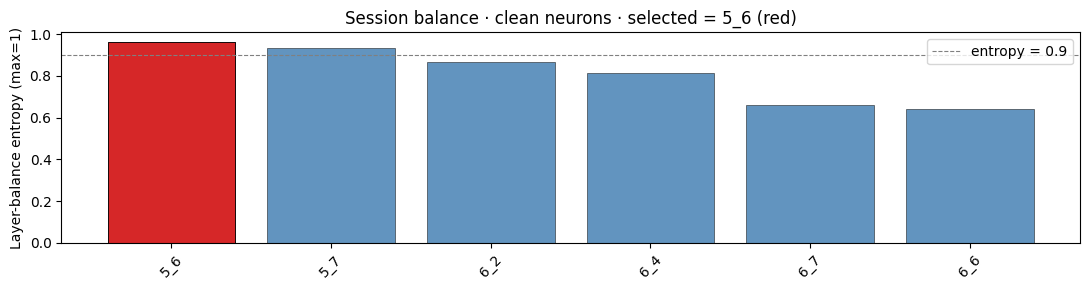


Selected session 5_6: n=685, entropy=0.961, min/max layer ratio = 0.386


In [3]:
session_ranking = find_balanced_session(units_clean, verbose=False)
non_degen = session_ranking[~session_ranking['degenerate']].reset_index(drop=True)
print(non_degen.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(len(non_degen)), non_degen['entropy'], color='steelblue', alpha=0.85,
       edgecolor='k', linewidth=0.4)
for i, sk in enumerate(non_degen['session_key']):
    if sk == SESSION:
        ax.bar([i], [non_degen.loc[i, 'entropy']], color='C3', edgecolor='k', linewidth=0.6)
ax.set_xticks(range(len(non_degen)))
ax.set_xticklabels(non_degen['session_key'], rotation=45)
ax.set_ylabel('Layer-balance entropy (max=1)')
ax.axhline(0.9, color='gray', ls='--', lw=0.8, label='entropy = 0.9')
ax.set_title(f'Session balance · clean neurons · selected = {SESSION} (red)')
ax.legend()
plt.tight_layout(); plt.show()

row = non_degen[non_degen['session_key'] == SESSION].iloc[0]
print(f"\nSelected session {SESSION}: n={row['total']}, entropy={row['entropy']:.3f}, "
      f"min/max layer ratio = {row['min_max_ratio']:.3f}")

## 3 · Build the E1 dataset for this session (§2.2)

One row per `(nucleus_id × oracle condition_hash)`, restricted to the 116 oracle hashes for which Phase-1 confirmed cross-session-stable axes. Every row carries the within-hash trial-averaged trace; **trials repeated within the same hash are averaged**, **different hashes are never combined** (§2.3).

In [4]:
df_session = build_single_session_e1(SESSION, units_clean, verbose=True)

# Sanity contracts (fail loudly rather than silently allow leakage / wrong shapes)
assert df_session['response_avg'].notna().all(),                            'NaN traces present'
assert set(df_session['layer_label']).issubset({'L2/3','L4','L5','L6'}),    'unexpected layer labels'
cov = df_session.groupby('nucleus_id')['condition_hash'].nunique()
assert (cov == 116).all(), f'oracle coverage not 116 for some neurons: min={cov.min()}'

n_neurons = df_session['nucleus_id'].nunique()
print(f'\nNeurons : {n_neurons}')
print(f'Rows    : {len(df_session):,}  (expected 116 × neurons = {116 * n_neurons:,})')
print('\nLayer distribution (per neuron):')
print(df_session.drop_duplicates('nucleus_id')['layer_label'].value_counts().sort_index().to_string())
print('\nTrace lengths by family (frames):')
print(df_session.groupby('stim_type')['n_frames'].agg(['min','max','count']).to_string())

Session 5_6: 685 clean neurons
layer_label
L2/3    151
L4      249
L5      189
L6       96

E1 rows: 79,460  (expected ~79,460)
Neurons with data: 685
Oracle hashes covered: 116

Rows by family:
stim_type
Clip      65760
Monet2     6850
Trippy     6850

Neurons : 685
Rows    : 79,460  (expected 116 × neurons = 79,460)

Layer distribution (per neuron):
layer_label
L2/3    151
L4      249
L5      189
L6       96

Trace lengths by family (frames):
           min  max  count
stim_type                 
Clip        75   75  65760
Monet2     113  113   6850
Trippy     113  113   6850


## 4 · CV folds — GroupKFold by `nucleus_id` (§6.4)

We pre-compute the 5 GKF test-fold assignments on the **set of unique neurons**, then propagate to rows. For each test fold $k$ we use $(k+1) \bmod 5$ as the validation fold for early stopping; the remaining three folds form the training set. This guarantees that a neuron contributes to exactly one of `{train, val, test}` per outer fold.

In [5]:
neurons_df = df_session[['nucleus_id', 'layer_label']].drop_duplicates().reset_index(drop=True)
neuron_ids = neurons_df['nucleus_id'].to_numpy()

# `groups` is itself the neuron id, so every group has size 1 — GKF degenerates to
# a deterministic, balanced partition of neurons across folds (5 disjoint blocks).
gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_neuron = np.full(len(neuron_ids), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(neuron_ids, groups=neuron_ids)):
    fold_of_neuron[te_idx] = k
assert (fold_of_neuron >= 0).all()
neurons_df['gkf_fold'] = fold_of_neuron

fold_layer_counts = (
    neurons_df.groupby(['gkf_fold', 'layer_label']).size().unstack(fill_value=0)
)
print('Neurons per fold × layer:')
print(fold_layer_counts.to_string())
assert (fold_layer_counts > 0).all().all(), 'Some fold has 0 neurons of some layer'

df_session = df_session.merge(neurons_df[['nucleus_id', 'gkf_fold']], on='nucleus_id', how='left')
print(f"\nTotal rows: {len(df_session):,};  rows per fold: "
      + ', '.join(f'fold {k}={(df_session["gkf_fold"]==k).sum():,}' for k in range(N_FOLDS)))

Neurons per fold × layer:
layer_label  L2/3  L4  L5  L6
gkf_fold                     
0              32  50  36  19
1              29  51  37  20
2              29  52  37  19
3              29  49  40  19
4              32  47  39  19

Total rows: 79,460;  rows per fold: fold 0=15,892, fold 1=15,892, fold 2=15,892, fold 3=15,892, fold 4=15,892


## 5 · Per-fold runner — one CNN, one condition, one fold

The runner extracts padded `(X, mask, y, groups)` for `train / val / test`, optionally applies the control transform on the train/val/test arrays *after* baseline-subtraction (so amplitude-only & time-shuffle controls are applied to the same input distribution the CNN saw in the matched non-control run), trains a `SmallTraceCNN` with masked GAP, then scores at the **neuron level** via mean-of-probabilities (E1 hash-uniform aggregation).

In [6]:
def _arrays_from_split(df_split):
    X, m, y, g = get_padded_arrays(df_split)
    return X.astype(np.float32), m.astype(np.float32), y, g.astype(np.int64)

def _apply_control(X_tr, X_va, X_te, control: str, fold_seed: int):
    if control == 'identity':
        return X_tr, X_va, X_te
    if control == 'time_shuffled':
        return (
            make_time_shuffled_traces(X_tr, seed=fold_seed +   0),
            make_time_shuffled_traces(X_va, seed=fold_seed + 100),
            make_time_shuffled_traces(X_te, seed=fold_seed + 200),
        )
    if control == 'amplitude_only':
        return (
            make_amplitude_only_traces(X_tr, mode='mean'),
            make_amplitude_only_traces(X_va, mode='mean'),
            make_amplitude_only_traces(X_te, mode='mean'),
        )
    raise ValueError(f'unknown control: {control!r}')

def run_one_fold(
    df_session: pd.DataFrame,
    fold_k: int,
    *,
    normalization: str,    # 'raw' | 'baseline_sub'
    control: str,          # 'identity' | 'time_shuffled' | 'amplitude_only'
    seed: int,
    verbose: bool = False,
):
    val_k = (fold_k + 1) % N_FOLDS

    df_te = df_session[df_session['gkf_fold'] == fold_k]
    df_va = df_session[df_session['gkf_fold'] == val_k]
    df_tr = df_session[~df_session['gkf_fold'].isin([fold_k, val_k])]

    nids_tr = set(df_tr['nucleus_id'].unique())
    nids_va = set(df_va['nucleus_id'].unique())
    nids_te = set(df_te['nucleus_id'].unique())
    assert nids_tr.isdisjoint(nids_va) and nids_tr.isdisjoint(nids_te) and nids_va.isdisjoint(nids_te), \
        'neuron leakage detected'

    if normalization == 'raw':
        df_tr_n, df_va_n, df_te_n = df_tr, df_va, df_te
    elif normalization == 'baseline_sub':
        df_tr_n = baseline_subtract_traces(df_tr, n_baseline_frames=N_BASELINE)
        df_va_n = baseline_subtract_traces(df_va, n_baseline_frames=N_BASELINE)
        df_te_n = baseline_subtract_traces(df_te, n_baseline_frames=N_BASELINE)
    else:
        raise ValueError(f'unknown normalization: {normalization!r}')

    X_tr, m_tr, y_tr, g_tr = _arrays_from_split(df_tr_n)
    X_va, m_va, y_va, g_va = _arrays_from_split(df_va_n)
    X_te, m_te, y_te, g_te = _arrays_from_split(df_te_n)

    X_tr, X_va, X_te = _apply_control(X_tr, X_va, X_te, control, fold_seed=seed + fold_k)

    model, history = train_fold(
        X_tr, y_tr, g_tr,
        X_va, y_va, g_va,
        mask_train=m_tr, mask_val=m_va,
        in_channels=1,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE,
        seed=seed + fold_k,
        device=DEVICE,
        verbose=verbose,
    )

    row_probs = predict_proba(model, X_te, mask=m_te, device=DEVICE)
    score = neuron_level_score(
        y_te, row_probs, g_te, classes=np.array(LAYER_CLASSES)
    )
    return score, history

print('Per-fold runner ready.')

Per-fold runner ready.


## 6 · Run all conditions × 5 folds

Four conditions × five folds = 20 trained models. Each fold reuses the same partition of neurons across conditions, so condition deltas are paired at the fold level for the §8 analysis.

Conditions:

* **`raw_identity`** — full information (offset + amplitude + temporal order).
* **`baseline_sub_identity`** — pre-stimulus median removed; offset stripped, amplitude & temporal order preserved.
* **`raw_time_shuffled`** — temporal order destroyed (per-trace permutation); marginal amplitude distribution preserved.
* **`raw_amplitude_only`** — every trace replaced by its mean; only the scalar amplitude survives.

In [7]:
CONDITIONS = [
    # (label, normalization, control)
    ('raw_identity',          'raw',          'identity'),
    ('baseline_sub_identity', 'baseline_sub', 'identity'),
    ('raw_time_shuffled',     'raw',          'time_shuffled'),
    ('raw_amplitude_only',    'raw',          'amplitude_only'),
]

results   = {label: [] for label, *_ in CONDITIONS}    # list of per-fold score dicts
histories = {label: [] for label, *_ in CONDITIONS}    # list of per-fold training histories

t0 = time.time()
for label, norm, ctrl in CONDITIONS:
    print(f'\n────────────────────  {label}  ────────────────────')
    for k in range(N_FOLDS):
        ti = time.time()
        score, hist = run_one_fold(
            df_session, fold_k=k,
            normalization=norm, control=ctrl,
            seed=SEED, verbose=False,
        )
        score['fold'] = k
        results[label].append(score)
        histories[label].append(hist)
        ba  = score['balanced_accuracy']
        f1  = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  fold {k} | n_test={score["n_neurons"]:3d} | bal_acc={ba:.4f} '
              f'| macro-F1={f1:.4f} | recall: '
              + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
              + f'  ({time.time() - ti:.1f}s)')
print(f'\nTotal training time: {(time.time() - t0) / 60:.1f} min')


────────────────────  raw_identity  ────────────────────
  fold 0 | n_test=137 | bal_acc=0.5728 | macro-F1=0.5162 | recall: L2/3=0.31 L4=0.34 L5=0.64 L6=1.00  (26.6s)
  fold 1 | n_test=137 | bal_acc=0.4852 | macro-F1=0.3926 | recall: L2/3=0.41 L4=0.12 L5=0.46 L6=0.95  (42.0s)
  fold 2 | n_test=137 | bal_acc=0.4344 | macro-F1=0.3591 | recall: L2/3=0.10 L4=0.44 L5=0.30 L6=0.89  (22.6s)
  fold 3 | n_test=137 | bal_acc=0.4454 | macro-F1=0.3512 | recall: L2/3=0.07 L4=0.39 L5=0.33 L6=1.00  (44.2s)
  fold 4 | n_test=137 | bal_acc=0.4854 | macro-F1=0.3465 | recall: L2/3=0.53 L4=0.00 L5=0.41 L6=1.00  (52.7s)

────────────────────  baseline_sub_identity  ────────────────────
  fold 0 | n_test=137 | bal_acc=0.4985 | macro-F1=0.4273 | recall: L2/3=0.44 L4=0.14 L5=0.42 L6=1.00  (24.3s)
  fold 1 | n_test=137 | bal_acc=0.4957 | macro-F1=0.4172 | recall: L2/3=0.28 L4=0.27 L5=0.43 L6=1.00  (49.3s)
  fold 2 | n_test=137 | bal_acc=0.4753 | macro-F1=0.3971 | recall: L2/3=0.34 L4=0.23 L5=0.38 L6=0.95  (34

## 7 · Summary table — mean ± std over folds

Mean and standard deviation across the 5 GKF folds, plus per-class recall as the across-fold mean of the per-fold recalls (`np.nanmean` so any degenerate per-fold cases — should not happen here — do not corrupt the average).

In [8]:
def summarise(scores):
    bas = np.array([s['balanced_accuracy'] for s in scores])
    f1s = np.array([s['macro_f1']          for s in scores])
    pcr_per_fold = {c: np.array([s['per_class_recall'][c] for s in scores]) for c in LAYER_CLASSES}
    return {
        'bal_acc_mean':  bas.mean(),
        'bal_acc_std':   bas.std(ddof=0),
        'macro_f1_mean': f1s.mean(),
        'macro_f1_std':  f1s.std(ddof=0),
        **{f'recall_{c}_mean': np.nanmean(pcr_per_fold[c]) for c in LAYER_CLASSES},
        **{f'recall_{c}_std':  np.nanstd (pcr_per_fold[c]) for c in LAYER_CLASSES},
    }

summary_rows = []
for label, _, _ in CONDITIONS:
    s = summarise(results[label])
    summary_rows.append({
        'condition': label,
        'bal_acc':   f"{s['bal_acc_mean']:.4f} ± {s['bal_acc_std']:.4f}",
        'macro_F1':  f"{s['macro_f1_mean']:.4f} ± {s['macro_f1_std']:.4f}",
        'L2/3':      f"{s['recall_L2/3_mean']:.3f} ± {s['recall_L2/3_std']:.3f}",
        'L4':        f"{s['recall_L4_mean']:.3f} ± {s['recall_L4_std']:.3f}",
        'L5':        f"{s['recall_L5_mean']:.3f} ± {s['recall_L5_std']:.3f}",
        'L6':        f"{s['recall_L6_mean']:.3f} ± {s['recall_L6_std']:.3f}",
    })
summary_df = pd.DataFrame(summary_rows).set_index('condition')
print(f'Stage 2.1 · session {SESSION} · 5-fold GKF by nucleus_id\n')
print(summary_df.to_string())

Stage 2.1 · session 5_6 · 5-fold GKF by nucleus_id

                               bal_acc         macro_F1           L2/3             L4             L5             L6
condition                                                                                                          
raw_identity           0.4847 ± 0.0487  0.3931 ± 0.0636  0.286 ± 0.178  0.258 ± 0.170  0.426 ± 0.121  0.969 ± 0.042
baseline_sub_identity  0.4851 ± 0.0107  0.4032 ± 0.0164  0.279 ± 0.124  0.284 ± 0.115  0.387 ± 0.037  0.989 ± 0.021
raw_time_shuffled      0.4850 ± 0.0231  0.3995 ± 0.0331  0.294 ± 0.122  0.262 ± 0.114  0.405 ± 0.077  0.979 ± 0.025
raw_amplitude_only     0.4937 ± 0.0150  0.4327 ± 0.0242  0.234 ± 0.241  0.438 ± 0.249  0.417 ± 0.083  0.887 ± 0.072


## 8 · Paired condition deltas (per-fold pairing)

Because each fold uses the *same* test neurons across conditions, balanced accuracies are paired. Per-fold deltas are more informative than the difference of means: a positive Δ on most folds is meaningful even if absolute accuracies are noisy.

* **Δ_baseline = raw − baseline_sub** : positive ⇒ model relies on offset (baseline subtraction *hurt* it).
* **Δ_temporal = raw − time_shuffled** : positive ⇒ direct evidence that **temporal order** carries information.
* **Δ_amplitude = raw − amplitude_only** : positive ⇒ the trace shape adds information **beyond** the scalar amplitude.

In [9]:
ba_per_fold = {label: np.array([s['balanced_accuracy'] for s in results[label]]) for label, *_ in CONDITIONS}

delta_rows = []
pairs = [
    ('Δ_baseline   = raw − baseline_sub',  'raw_identity', 'baseline_sub_identity'),
    ('Δ_temporal   = raw − time_shuffled', 'raw_identity', 'raw_time_shuffled'),
    ('Δ_amplitude  = raw − amplitude_only','raw_identity', 'raw_amplitude_only'),
]
for name, a, b in pairs:
    d = ba_per_fold[a] - ba_per_fold[b]
    delta_rows.append({
        'comparison': name,
        'fold0': f'{d[0]:+.3f}', 'fold1': f'{d[1]:+.3f}',
        'fold2': f'{d[2]:+.3f}', 'fold3': f'{d[3]:+.3f}',
        'fold4': f'{d[4]:+.3f}',
        'mean Δ': f'{d.mean():+.4f}',
        'std Δ':  f'{d.std(ddof=0):.4f}',
        'n_pos/5': int((d > 0).sum()),
    })
delta_df = pd.DataFrame(delta_rows).set_index('comparison')
print('Per-fold paired deltas (balanced accuracy):\n')
print(delta_df.to_string())

Per-fold paired deltas (balanced accuracy):

                                      fold0   fold1   fold2   fold3   fold4   mean Δ   std Δ  n_pos/5
comparison                                                                                           
Δ_baseline   = raw − baseline_sub    +0.074  -0.010  -0.041  -0.026  +0.001  -0.0004  0.0400        2
Δ_temporal   = raw − time_shuffled   +0.063  -0.016  -0.047  +0.002  -0.003  -0.0003  0.0358        2
Δ_amplitude  = raw − amplitude_only  +0.083  -0.002  -0.037  -0.064  -0.026  -0.0091  0.0503        1


## 9 · Plots — bal-acc per fold × condition and aggregated confusion of `raw_identity`

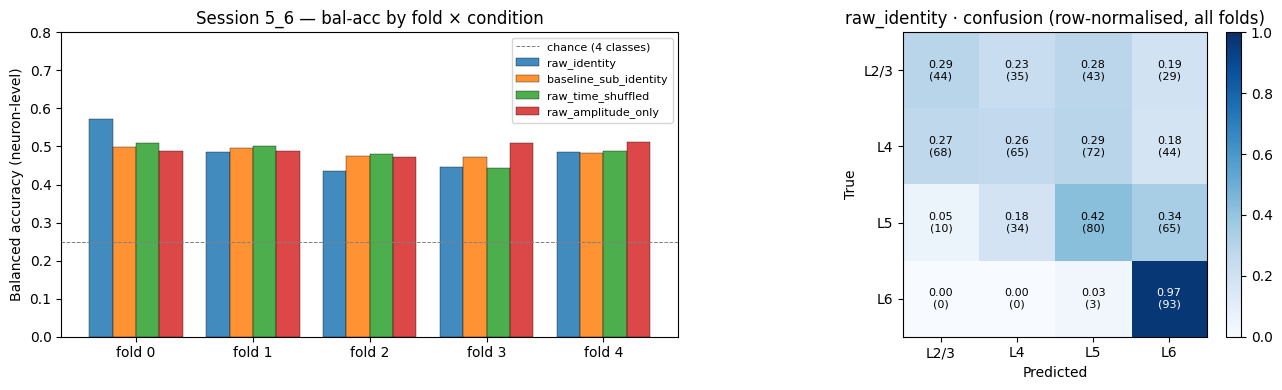

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x = np.arange(N_FOLDS)
width = 0.20
for i, (label, *_ ) in enumerate(CONDITIONS):
    ax.bar(x + (i - 1.5) * width, ba_per_fold[label], width=width,
           label=label, alpha=0.85, edgecolor='k', linewidth=0.3)
ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance (4 classes)')
ax.set_xticks(x)
ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
ax.set_ylabel('Balanced accuracy (neuron-level)')
ax.set_title(f'Session {SESSION} — bal-acc by fold × condition')
y_top = max(0.8, max(ba_per_fold[lbl].max() for lbl, *_ in CONDITIONS) + 0.05)
ax.set_ylim(0.0, y_top)
ax.legend(fontsize=8, loc='upper right')

ax = axes[1]
C = sum(s['confusion_matrix'] for s in results['raw_identity'])
C_norm = C / C.sum(axis=1, keepdims=True).clip(min=1)
im = ax.imshow(C_norm, vmin=0, vmax=1, cmap='Blues')
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax.text(j, i, f'{C_norm[i,j]:.2f}\n({C[i,j]})',
                ha='center', va='center', fontsize=8,
                color='white' if C_norm[i,j] > 0.5 else 'black')
ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES)
ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('raw_identity · confusion (row-normalised, all folds)')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)

plt.tight_layout(); plt.show()

## 10 · Training curves

Mean ± SD across folds of the train CE loss and the validation neuron-level balanced accuracy, for `raw_identity` and `baseline_sub_identity`. A flat training loss with a chance-level validation curve is the signature the plan warns about: not a tuning issue but a *representation* issue.

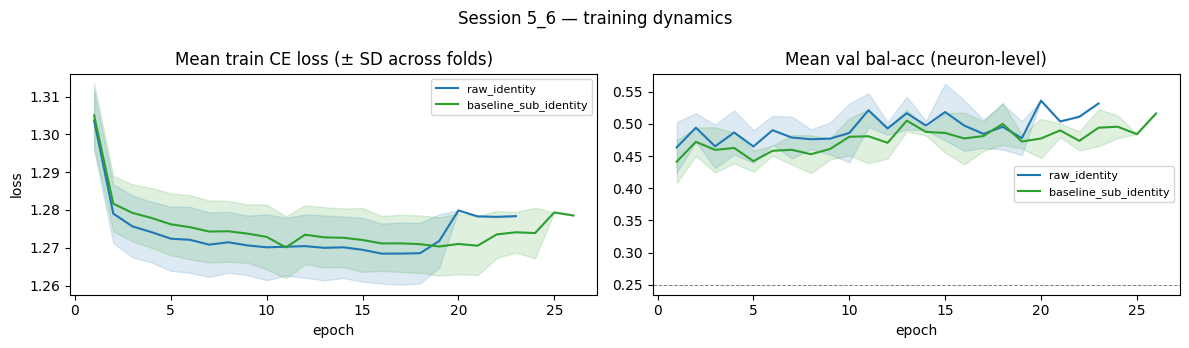

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for label, color in [('raw_identity', 'C0'), ('baseline_sub_identity', 'C2')]:
    hists = histories[label]
    max_e = max(len(h) for h in hists)
    loss = np.full((len(hists), max_e), np.nan)
    vacc = np.full((len(hists), max_e), np.nan)
    for i, h in enumerate(hists):
        loss[i, :len(h)] = [r['train_loss']  for r in h]
        vacc[i, :len(h)] = [r['val_bal_acc'] for r in h]
    epochs = np.arange(1, max_e + 1)
    axes[0].plot(epochs, np.nanmean(loss, 0), color=color, label=label)
    axes[0].fill_between(epochs,
                         np.nanmean(loss, 0) - np.nanstd(loss, 0),
                         np.nanmean(loss, 0) + np.nanstd(loss, 0),
                         color=color, alpha=0.15)
    axes[1].plot(epochs, np.nanmean(vacc, 0), color=color, label=label)
    axes[1].fill_between(epochs,
                         np.nanmean(vacc, 0) - np.nanstd(vacc, 0),
                         np.nanmean(vacc, 0) + np.nanstd(vacc, 0),
                         color=color, alpha=0.15)
axes[0].set(title='Mean train CE loss (± SD across folds)', xlabel='epoch', ylabel='loss')
axes[1].set(title='Mean val bal-acc (neuron-level)',         xlabel='epoch')
axes[1].axhline(0.25, color='gray', ls='--', lw=0.7)
for ax in axes:
    ax.legend(fontsize=8)
plt.suptitle(f'Session {SESSION} — training dynamics')
plt.tight_layout(); plt.show()

## 11 · Interpretation (per planning §10)

We classify the outcome along three axes — **above-chance**, **offset reliance**, **temporal order**, **amplitude sufficiency** — and report the corresponding allowed scientific reading. The thresholds are intentionally conservative:

* `raw` is considered to *succeed* if mean balanced accuracy exceeds chance (`0.25`) by ≥ 5 percentage points;
* a paired Δ in balanced accuracy is *meaningful* only if its absolute value exceeds `EPS_DELTA = 0.01` (i.e. ≥ 1 pp on average across folds).

In [12]:
EPS_DELTA = 0.01  # threshold below which a delta is treated as 'no clear difference'

ba_raw  = ba_per_fold['raw_identity'].mean()
ba_bsub = ba_per_fold['baseline_sub_identity'].mean()
ba_shuf = ba_per_fold['raw_time_shuffled'].mean()
ba_amp  = ba_per_fold['raw_amplitude_only'].mean()

d_baseline  = ba_raw - ba_bsub
d_temporal  = ba_raw - ba_shuf
d_amplitude = ba_raw - ba_amp

raw_above_chance  = ba_raw  - 0.25
bsub_above_chance = ba_bsub - 0.25

verdicts = []

if raw_above_chance < 0.05:
    verdicts.append('FAILURE: raw CNN does not beat chance by ≥ 5 pp on this session. '
                    'Architecture, preprocessing, trace window, or representation is insufficient. '
                    'Do NOT attempt LOSO before debugging this. (planning §10)')
else:
    verdicts.append(f'Raw CNN beats chance: {ba_raw:.3f} (Δ vs chance = {raw_above_chance:+.3f}).')

    if d_baseline > EPS_DELTA and bsub_above_chance < 0.03:
        verdicts.append(f'OFFSET-DRIVEN: removing baseline offset collapses the model '
                        f'(raw {ba_raw:.3f} → bsub {ba_bsub:.3f}, Δ={d_baseline:+.3f}). '
                        f'Performance reflects within-session offset/baseline more than evoked dynamics.')
    elif abs(d_baseline) <= EPS_DELTA:
        verdicts.append(f'Offset is not the driver: baseline-subtracted ≈ raw '
                        f'(Δ_baseline={d_baseline:+.3f}).')
    elif d_baseline < -EPS_DELTA:
        verdicts.append(f'Baseline-subtracted IMPROVES over raw (Δ={d_baseline:+.3f}); '
                        f'offset is a confound that the CNN benefits from removing.')
    else:
        verdicts.append(f'Raw modestly above bsub (Δ={d_baseline:+.3f}); '
                        f'offset contributes some signal but is not the only driver.')

    if d_temporal > EPS_DELTA:
        verdicts.append(f'TEMPORAL ORDER MATTERS: raw beats time-shuffled '
                        f'(Δ_temporal={d_temporal:+.3f}). Within-session evidence that the CNN uses '
                        f'the *order* of frames, not just their distribution.')
    elif abs(d_temporal) <= EPS_DELTA:
        verdicts.append(f'Temporal order does NOT contribute: raw ≈ time-shuffled '
                        f'(Δ_temporal={d_temporal:+.3f}). The CNN is using the marginal amplitude '
                        f'distribution, not response kinetics. Kinetics claims are NOT allowed.')
    else:
        verdicts.append(f'Time-shuffled is BETTER than raw (Δ_temporal={d_temporal:+.3f}); suspicious — '
                        f'either noise destroys a fragile signal or shuffling acts as accidental regularisation.')

    if d_amplitude > EPS_DELTA:
        verdicts.append(f'BEYOND AMPLITUDE: raw beats amplitude-only (Δ_amplitude={d_amplitude:+.3f}). '
                        f'The trace contributes information that a single scalar amplitude does not capture.')
    elif abs(d_amplitude) <= EPS_DELTA:
        verdicts.append(f'AMPLITUDE-EQUIVALENT: raw ≈ amplitude-only (Δ_amplitude={d_amplitude:+.3f}). '
                        f'Within this session, a single per-trace mean is as informative as the full trace.')
    else:
        verdicts.append(f'Amplitude-only OUTPERFORMS raw (Δ_amplitude={d_amplitude:+.3f}); '
                        f'CNN may be over-fitting noise.')

    if d_temporal > EPS_DELTA and d_amplitude > EPS_DELTA and bsub_above_chance > 0.03:
        verdicts.append('PROCEED to Stage 2.2 (E0 trial-level), then Stage 2.3 (replication on a second '
                       'balanced session, e.g. 5_7), then Stage 2.4 (5_6 ↔ 5_7 transfer). (planning §7)')
    else:
        verdicts.append('Stage 2.2 (E0) may still be informative, but the strong cross-session claims of '
                       'planning §11 require Δ_temporal > 0 AND Δ_amplitude > 0. Plan saliency / occlusion '
                       'before any kinetics claim. (planning §11)')

print('Stage 2.1 verdict:')
for v in verdicts:
    print('  • ' + v)

Stage 2.1 verdict:
  • Raw CNN beats chance: 0.485 (Δ vs chance = +0.235).
  • Offset is not the driver: baseline-subtracted ≈ raw (Δ_baseline=-0.000).
  • Temporal order does NOT contribute: raw ≈ time-shuffled (Δ_temporal=-0.000). The CNN is using the marginal amplitude distribution, not response kinetics. Kinetics claims are NOT allowed.
  • AMPLITUDE-EQUIVALENT: raw ≈ amplitude-only (Δ_amplitude=-0.009). Within this session, a single per-trace mean is as informative as the full trace.
  • Stage 2.2 (E0) may still be informative, but the strong cross-session claims of planning §11 require Δ_temporal > 0 AND Δ_amplitude > 0. Plan saliency / occlusion before any kinetics claim. (planning §11)


## 12 · Persist results

Saves one row per `(condition × fold)` and one summary row per condition (`fold_or_session = '<SESSION>_summary'`) to `data/processed/results/phase2_stage2_1_single_session.parquet`. Downstream notebooks (Stage 2.2 onwards) join on this file.

In [13]:
rows = []
for label, norm, ctrl in CONDITIONS:
    for k, score in enumerate(results[label]):
        rows.append(make_result_row(
            model_name      = f'CNN_E1_{label}',
            input_mode      = 'E1_padded_oracle',
            normalization   = norm,
            stimulus_family = 'all_padded',
            split_protocol  = f'within_session_GKF{N_FOLDS}',
            fold_or_session = f'{SESSION}_fold{k}',
            seed            = SEED + k,
            score_dict      = score,
            notes           = (f'Stage 2.1 single-session probe; control={ctrl}; '
                               'mismatch removed; padded T=113; masked GAP'),
        ))
    s = summarise(results[label])
    rows.append({
        'model_name':        f'CNN_E1_{label}',
        'input_mode':        'E1_padded_oracle',
        'normalization':     norm,
        'stimulus_family':   'all_padded',
        'split_protocol':    f'within_session_GKF{N_FOLDS}',
        'fold_or_session':   f'{SESSION}_summary',
        'seed':              SEED,
        'n_neurons':         int(np.mean([sc['n_neurons'] for sc in results[label]])),
        'balanced_accuracy': float(s['bal_acc_mean']),
        'macro_f1':          float(s['macro_f1_mean']),
        'recall_L23':        float(s['recall_L2/3_mean']),
        'recall_L4':         float(s['recall_L4_mean']),
        'recall_L5':         float(s['recall_L5_mean']),
        'recall_L6':         float(s['recall_L6_mean']),
        'notes':             (f'Stage 2.1 SUMMARY (mean over {N_FOLDS} folds); control={ctrl}; '
                              f'bal_acc_std={s["bal_acc_std"]:.4f}'),
    })

save_results(rows, 'phase2_stage2_1_single_session.parquet')
print(f'Saved {len(rows)} rows → data/processed/results/phase2_stage2_1_single_session.parquet')

Saved 24 row(s) → data/processed/results/phase2_stage2_1_single_session.parquet  (total: 24)
Saved 24 rows → data/processed/results/phase2_stage2_1_single_session.parquet


Stage 2.1 shows that E1 raw traces contain within-session layer-discriminative information, with mean balanced accuracy around 0.485, well above chance. However, baseline subtraction produces essentially identical performance, indicating that a simple vertical baseline offset is not the main driver. Time-shuffled traces also perform essentially identically to intact traces, and the amplitude-only baseline is slightly higher on average. Therefore, within this single session and this row-level CNN design, the decodable signal is amplitude-equivalent rather than temporal-order-dependent. Kinetics claims are not supported at this stage.

---

### What this notebook does NOT claim

* **No cross-session claim.** All metrics are within-session; per planning §1.2 and §10 the cross-session question is deferred to Stages 2.4–2.7.
* **No engineered-tier comparison.** Tier-G / Tier-A / multimodal benchmarks are deferred to the end-of-Phase-2 benchmark notebook.
* **No kinetics claim** unless Δ_temporal > 0, Δ_amplitude > 0, baseline-subtracted does not collapse, **and** saliency / occlusion (a future notebook) localises signal to evoked windows (planning §11 last item).

### Next notebook

**Stage 2.2 — E0 trial-level feasibility on the same session 5_6.** Same architecture, same controls, same GKF folds; rows are `(neuron, hash, trial)` and we report **both** row-uniform and hash-uniform aggregations to test whether trial-level variability adds information beyond the within-hash mean.